In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import importlib
import modules
importlib.reload(modules)
from utils import *
import copy
import os
import scipy.io as sio
from sklearn.metrics import confusion_matrix, roc_curve, auc
DTYPE = torch.float32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def experiment(data_path, save_path, num_cluster, experiment_repeats=2, repeats=2, epochs=200):

    out_dir = os.path.dirname(save_path)
    os.makedirs(out_dir, exist_ok=True)

    data      = sio.loadmat(data_path)
    samples   = torch.tensor(data['X'], dtype=DTYPE)


    labels    = torch.tensor(data['y'], dtype=DTYPE).view(-1)-1
    voc_names = [str(v.flat[0]) for v in data['voc_names'].flatten()]  # (699,)

    # 固定 test set
    train_loader, test_loader, _ = split_dataset(
        samples, labels, batch_size=16, split_length=[0.8, 0.2])

    # x_pool / y_pool 顺序对齐（shuffle=False 重取）
    _tmp_loader = DataLoader(
        train_loader.dataset, batch_size=len(train_loader.dataset), shuffle=False)
    x_pool, y_pool = next(iter(_tmp_loader))

    # KMeans 固定，用整个 x_pool（test 已分离，无泄漏）
    k_means_mask = feature_cluster(x_pool.float().numpy(), num_cluster)

    # y = data['y'].flatten()
    # unique, counts = np.unique(y, return_counts=True)
    # for cls, cnt in zip(unique, counts):
    #     print(f"类别{int(cls)}: {cnt}个  →  0.8={int(cnt*0.8)}, 0.2={cnt-int(cnt*0.8)}")

    all_masks   = []
    all_binary  = []
    all_cm      = []
    all_probs   = []
    all_targets = []

    pbar = tqdm(range(experiment_repeats))

    for out_idx in pbar:

        # 每组重新随机划分 train/val（内循环 10 次共用同一划分）
        train_loader_init, val_loader, x_train = split_dataset(
            x_pool, y_pool, batch_size=16, split_length=[0.75, 0.25])
        x_val = torch.cat([x for x, _ in val_loader])

        group_best_acc  = -1.0
        group_best_mask = None
        group_best_wts  = None

        for in_idx in range(repeats):

            model = MultiView(
                k_mean_mask=k_means_mask,
                num_blocks=1,
                head_dim=32,
                num_class=2
            ).to(DEVICE, dtype=DTYPE)

            optimizer = optim.Adam([
                {'params': model.logist.parameters(),         'lr': 1e-5, 'weight_decay': 1e-4},
                {'params': model.mlp_classifier.parameters(), 'lr': 5e-4, 'weight_decay': 5e-3},
            ])
            criterion       = nn.CrossEntropyLoss()
            local_best_acc  = 0.0
            local_best_wts  = None
            local_best_mask = None

            for epoch in range(epochs):
                model.train()
                for x, y in train_loader_init:
                    x, y = x.to(DEVICE, dtype=DTYPE), y.to(DEVICE, dtype=DTYPE).squeeze().long()
                    optimizer.zero_grad()
                    outputs, mask = model(x)
                    loss = criterion(outputs, y) + mask.mean() * 1e-2
                    loss.backward()
                    optimizer.step()

                model.eval()
                correct, total_n = 0.0, 0.0
                with torch.no_grad():
                    mask_score = model.get_score(x_val.to(DEVICE, dtype=DTYPE))
                    for x, y in val_loader:
                        x, y = x.to(DEVICE, dtype=DTYPE), y.to(DEVICE, dtype=DTYPE)
                        outputs  = model.mlp_classifier(x * mask_score)
                        correct += (torch.argmax(outputs, 1) == y).sum().item()
                        total_n += y.size(0)
                    acc = correct / total_n

                if acc > local_best_acc:
                    local_best_acc  = acc
                    local_best_wts  = copy.deepcopy(model.state_dict())
                    local_best_mask = mask_score.cpu()

            if local_best_acc > group_best_acc:
                group_best_acc  = local_best_acc
                group_best_wts  = local_best_wts
                group_best_mask = local_best_mask

        # 冠军模型 → test_loader 评估（唯一一次接触测试集）
        if group_best_wts is not None:
            model.load_state_dict(group_best_wts)
            model.eval()
            with torch.no_grad():
                g_preds, g_probs, g_targets = [], [], []
                m_final = (group_best_mask.to(DEVICE, DTYPE) > 0.5).to(DEVICE, dtype=DTYPE)
                for x_test, y_test in val_loader:
                    x_test  = x_test.to(DEVICE, dtype=DTYPE)
                    outputs = model.mlp_classifier(x_test * m_final)
                    probs   = torch.softmax(outputs.float(), dim=1)[:, 1]  # bfloat16→float 再 softmax
                    preds   = torch.argmax(outputs, 1)
                    g_preds.extend(preds.cpu().numpy())
                    g_probs.extend(probs.cpu().numpy())
                    g_targets.extend(y_test.float().cpu().numpy())

                group_best_cm = confusion_matrix(g_targets, g_preds, labels=[0, 1])

            all_masks.append(group_best_mask)
            all_binary.append((group_best_mask > 0.5).float())
            all_cm.append(torch.from_numpy(group_best_cm).unsqueeze(0).float())
            all_probs.append(np.array(g_probs))
            all_targets.append(np.array(g_targets))

    # ============================================================
    # 统计
    # ============================================================
    all_masks  = torch.stack(all_masks)    # [N, VOC数]
    all_binary = torch.stack(all_binary)

    selection_freq = all_binary.mean(dim=0).float().cpu().numpy()
    weight_std_tensor, weight_mean_tensor = torch.std_mean(all_masks, dim=0)
    w_mean = weight_mean_tensor.float().cpu().numpy()
    w_std  = weight_std_tensor.float().cpu().numpy()
    sem    = w_std / np.sqrt(experiment_repeats)

    sorted_idx  = np.argsort(selection_freq)[::-1]
    top_n       = int((w_mean > 0.5).sum())
    top_idx     = sorted_idx[:top_n]
    combined_cm = torch.cat(all_cm, dim=0)

    # ============================================================
    # 保存① all_masks
    # ============================================================
    torch.save(all_masks, save_path)

    # ============================================================
    # 保存② 特征选择统计表（含VOC名称）→ CSV
    # ============================================================
    feat_csv = os.path.join(out_dir, 'feature_selection_stats.csv')
    pd.DataFrame({
        'VOC_Index':      np.arange(len(w_mean)),
        'VOC_Name':       voc_names,
        'Selection_Freq': selection_freq,
        'Mean_Weight':    w_mean,
        'Std_Weight':     w_std,
        'SEM_Weight':     sem,
    }).to_csv(feat_csv, index=False)
    print(f"[保存②] 特征选择统计 → {feat_csv}")

    # ============================================================
    # 保存③ 混淆矩阵均值 → CSV
    # ============================================================
    cm_mean = combined_cm.mean(dim=0).numpy()
    cm_csv  = os.path.join(out_dir, 'confusion_matrix_summary.csv')
    pd.DataFrame(cm_mean,
                 index=['True_Neg', 'True_Pos'],
                 columns=['Pred_Neg', 'Pred_Pos']).to_csv(cm_csv)
    print(f"[保存③] 混淆矩阵均值 → {cm_csv}")

    # ============================================================
    # 保存④ 原始软概率+标签 → npz
    # ============================================================
    raw_npz = os.path.join(out_dir, 'raw_probs_targets.npz')
    np.savez(raw_npz,
             probs=np.array(all_probs, dtype=object),
             targets=np.array(all_targets, dtype=object))
    print(f"[保存④] 原始软概率与标签 → {raw_npz}")

    # ============================================================
    # 图① 特征重要性
    # ============================================================
    fig1, axes = plt.subplots(2, 1, figsize=(16, 8))
    axes[0].bar(range(top_n), selection_freq[top_idx], color='teal', alpha=0.7)
    axes[0].axhline(y=0.5, color='r', linestyle='--', label='Threshold 0.5')
    axes[0].set_title(f"Top {top_n} VOC Selection Frequency (n={experiment_repeats} groups)")
    axes[0].set_ylabel("Selection Probability")
    axes[0].set_ylim(0, 1.05)
    axes[0].legend()

    x_axis = range(top_n)
    m_plot, s_plot = w_mean[top_idx], sem[top_idx]
    axes[1].bar(x_axis, m_plot, color='coral', alpha=0.6, label='Mean Weight')
    axes[1].fill_between(x_axis, m_plot - s_plot, m_plot + s_plot,
                         color='gray', alpha=0.4, label='±SEM')
    axes[1].errorbar(x_axis, m_plot, yerr=w_std[top_idx],
                     fmt='none', ecolor='black', capsize=2, alpha=0.5, label='Std Dev')
    axes[1].set_title(f"Mean Weights of Top {top_n} Features (Ordered by Stability)")
    axes[1].set_ylabel("Mask Score")
    axes[1].set_xlabel("VOC Index (Ranked)")
    axes[1].legend()
    fig1.tight_layout()
    fig1_path = os.path.join(out_dir, 'feature_importance.png')
    fig1.savefig(fig1_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[保存⑤] 特征重要性图 → {fig1_path}")

    # ============================================================
    # 图② ROC 曲线
    # ============================================================
    fig2, ax = plt.subplots(figsize=(7, 7))
    tprs, aucs = [], []
    mean_fpr = np.linspace(0, 1, 200)

    for probs_i, targets_i in zip(all_probs, all_targets):
        fpr, tpr, _ = roc_curve(targets_i, probs_i)
        roc_auc     = auc(fpr, tpr)
        aucs.append(roc_auc)
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0
        ax.plot(fpr, tpr, color='steelblue', alpha=0.15, linewidth=0.8)

    mean_tpr     = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    std_tpr      = np.std(tprs, axis=0)
    mean_auc     = np.mean(aucs)
    std_auc      = np.std(aucs)

    ax.plot(mean_fpr, mean_tpr, color='navy', linewidth=2,
            label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})')
    ax.fill_between(mean_fpr,
                    np.maximum(mean_tpr - std_tpr, 0),
                    np.minimum(mean_tpr + std_tpr, 1),
                    color='steelblue', alpha=0.2, label='±1 SD')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Chance')
    ax.set_xlabel('False Positive Rate', fontsize=13)
    ax.set_ylabel('True Positive Rate', fontsize=13)
    ax.set_title(f'ROC Curve (n={experiment_repeats} champion models)', fontsize=14)
    ax.legend(loc='lower right', fontsize=11)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    fig2.tight_layout()
    roc_path = os.path.join(out_dir, 'roc_curve.png')
    fig2.savefig(roc_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[保存⑥] ROC 曲线 → {roc_path}")

    # ============================================================
    # 保存⑦ 逐组AUC → CSV
    # ============================================================
    auc_csv = os.path.join(out_dir, 'auc_per_group.csv')
    pd.DataFrame({'Group': np.arange(len(aucs)), 'AUC': aucs}).to_csv(auc_csv, index=False)
    print(f"[保存⑦] 逐组AUC → {auc_csv}")

    # ============================================================
    # 打印最终指标
    # ============================================================
    print("\n" + "="*50)
    print(f" 🌟 Final Report: Averaged over {experiment_repeats} champion models")
    print(f"    AUC = {mean_auc:.4f} ± {std_auc:.4f}")
    print_classification_result(combined_cm)
    print("="*50)

In [ ]:
experiment('./data/1_and_2.mat', './result/mask_l_results1-2.pt', num_cluster=3, experiment_repeats=100, repeats=20, epochs=300)
# experiment('./data/2_and_3.mat', './result/mask_l_results1-2.pt', num_cluster=3, experiment_repeats=100, repeats=10, epochs=300)
# experiment('./data/1+2_and_3.mat', './result/mask_l_results1-2.pt', num_cluster=3, experiment_repeats=100, repeats=10, epochs=300)

 96%|█████████▌| 96/100 [6:04:33<26:14, 393.64s/it]  

In [15]:
"""
VOC 二分类 - 干净 baseline + 特征稳定性
================================================
- 重复分层 K 折交叉验证 (无测试集泄漏)
- 所有预处理 (标准化 + 单变量过滤) 都在 Pipeline 内, 只在训练折 fit
- 输出: 4 个模型的 AUC/Acc/F1, 以及 L1 LogReg 的跨折特征选择频率
用法: 把 MAT 路径改成你的, 直接 python baseline.py
"""
import numpy as np
import pandas as pd
import scipy.io as sio
from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
import warnings; warnings.filterwarnings("ignore")

# ============================================================
# 1. 读数据  (注意: 你原标签是 1/2, 这里 -1 变成 0/1)
# ============================================================
MAT_PATH = "./data/1_and_2.mat"        # <-- 改成你自己的路径
d = sio.loadmat(MAT_PATH)
X = d["X"].astype(np.float64)                  # (n_samples, 699)
y = d["y"].reshape(-1).astype(int) - 1         # (n_samples,)  0/1
voc_names = [str(v.flat[0]) for v in d["voc_names"].flatten()]
print(f"X shape = {X.shape}    y 分布 = {Counter(y.tolist())}\n")

# ============================================================
# 2. 模型对比 (Pipeline 保证无泄漏)
# ============================================================
K_FEATURES = 30        # 单变量过滤保留多少 VOC, 可调 20/30/50

def make_pipe(clf):
    return Pipeline([
        ("scale",  StandardScaler()),
        ("select", SelectKBest(f_classif, k=K_FEATURES)),
        ("clf",    clf),
    ])

models = {
    "LogReg-L2":   make_pipe(LogisticRegression(C=1.0, max_iter=2000)),
    "LogReg-L1":   make_pipe(LogisticRegression(C=0.3, penalty="l1",
                                                solver="liblinear", max_iter=2000)),
    "LinearSVM":   make_pipe(LinearSVC(C=0.1, max_iter=3000, dual="auto")),
    "RandomForest":make_pipe(RandomForestClassifier(n_estimators=500,
                                                    min_samples_leaf=2,
                                                    random_state=0, n_jobs=-1)),
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)
print(f"{'Model':<14}{'AUC':<18}{'Acc':<18}{'F1':<18}")
print("-" * 68)
for name, pipe in models.items():
    # LinearSVC 没有 predict_proba, 用 decision_function 做 AUC
    scoring = {"accuracy": "accuracy", "f1": "f1"}
    if name == "LinearSVM":
        scoring["roc_auc"] = "roc_auc"   # 也能算, sklearn 内部会用 decision_function
    else:
        scoring["roc_auc"] = "roc_auc"
    out = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    fmt = lambda a: f"{a.mean():.3f}±{1.96*a.std()/np.sqrt(len(a)):.3f}"
    print(f"{name:<14}{fmt(out['test_roc_auc']):<18}"
          f"{fmt(out['test_accuracy']):<18}{fmt(out['test_f1']):<18}")

# ============================================================
# 3. 特征稳定性 (stability selection 思路)
#    跨所有折, 统计每个 VOC 被 L1 LogReg 选成非零系数的频率
# ============================================================
print("\n>>> 特征稳定性 (L1 LogReg 跨折非零频率)")
K_STAB = 50
counts = np.zeros(X.shape[1], dtype=int)
n_folds = 0
for tr, _ in cv.split(X, y):
    p = Pipeline([
        ("sc",  StandardScaler()),
        ("sel", SelectKBest(f_classif, k=K_STAB)),
        ("clf", LogisticRegression(C=0.3, penalty="l1",
                                   solver="liblinear", max_iter=2000)),
    ])
    p.fit(X[tr], y[tr])
    sel = p.named_steps["sel"].get_support(indices=True)
    nz  = np.where(p.named_steps["clf"].coef_.ravel() != 0)[0]
    counts[sel[nz]] += 1
    n_folds += 1
freq = counts / n_folds

# 导出稳定性表
df = pd.DataFrame({
    "VOC_Index":      np.arange(len(freq)),
    "VOC_Name":       voc_names,
    "Selection_Freq": freq,
}).sort_values("Selection_Freq", ascending=False)
df.to_csv("stability_selection.csv", index=False)
print(f"已保存: stability_selection.csv  (共 {n_folds} 折)")
print("\nTop-50 最稳定 VOC:")
for _, r in df.head(50).iterrows():
    if r.Selection_Freq == 0: break
    print(f"  freq={r.Selection_Freq:.2f}   idx={int(r.VOC_Index):3d}   {r.VOC_Name}")

X shape = (106, 699)    y 分布 = Counter({0: 53, 1: 53})

Model         AUC               Acc               F1                
--------------------------------------------------------------------
LogReg-L2     0.659±0.030       0.637±0.027       0.647±0.029       
LogReg-L1     0.705±0.031       0.670±0.029       0.667±0.029       
LinearSVM     0.656±0.028       0.640±0.027       0.647±0.029       
RandomForest  0.729±0.028       0.684±0.024       0.683±0.027       

>>> 特征稳定性 (L1 LogReg 跨折非零频率)
已保存: stability_selection.csv  (共 50 折)

Top-50 最稳定 VOC:
  freq=1.00   idx=151   246_1,5-Dimethyl-6-oxa-bicyclo[3.1.0]hexane
  freq=1.00   idx= 72   113_Unknown
  freq=0.76   idx=335   593_Nonane, 5-methyl-5-propyl-
  freq=0.74   idx=418   774_Unknown
  freq=0.72   idx=692   1520_Unknown
  freq=0.70   idx= 70   111_Unknown
  freq=0.66   idx= 73   114_Unknown
  freq=0.58   idx=529   1031_Unknown
  freq=0.56   idx=361   646_(+)-4-Carene
  freq=0.50   idx=185   315_1-Methoxycyclohexane
  freq=0.48  

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import importlib
import modules2
importlib.reload(modules2)
from utils import *
from modules2 import MultiView
import copy
import os
import json
import random
import scipy.io as sio
from scipy import stats
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score

DTYPE  = torch.float32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# 工具①：固定随机种子（复现性）
# ============================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# 工具②：由混淆矩阵 + 概率算全套诊断指标
#   confusion_matrix(labels=[0,1]) -> [[TN, FP],[FN, TP]]
# ============================================================
def compute_metrics(cm, targets, probs):
    tn, fp = float(cm[0, 0]), float(cm[0, 1])
    fn, tp = float(cm[1, 0]), float(cm[1, 1])
    eps = 1e-12
    sens = tp / (tp + fn + eps)          # 敏感度
    spec = tn / (tn + fp + eps)          # 特异度
    ppv  = tp / (tp + fp + eps)          # 阳性预测值
    npv  = tn / (tn + fn + eps)          # 阴性预测值
    acc  = (tp + tn) / (tp + tn + fp + fn + eps)
    f1   = 2 * ppv * sens / (ppv + sens + eps)
    try:
        auc_val = roc_auc_score(targets, probs)
    except ValueError:                   # 测试集单一类别时 AUC 算不出
        auc_val = np.nan
    return {'Sensitivity': sens, 'Specificity': spec, 'PPV': ppv, 'NPV': npv,
            'Accuracy': acc, 'F1': f1, 'AUC': auc_val}


# ============================================================
# 工具③：跨 repeat 的均值 + 95% CI（小样本用 t 分布）
# ============================================================
def mean_ci(values, alpha=0.05):
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    n = len(v)
    m = float(v.mean()) if n > 0 else np.nan
    if n < 2:
        return m, np.nan, np.nan, np.nan, np.nan
    sd    = float(v.std(ddof=1))
    sem   = sd / np.sqrt(n)
    tcrit = stats.t.ppf(1 - alpha / 2, df=n - 1)
    return m, sd, sem, m - tcrit * sem, m + tcrit * sem


def experiment(data_path, save_path, num_cluster,
               experiment_repeats=2, repeats=2, epochs=200,
               sparsity_lambda=1e-2,
               temp_start=1.0, temp_end=0.3,
               seed=42, panel_threshold=0.5):

    # ---- 固定种子 ----
    set_seed(seed)

    out_dir = os.path.dirname(save_path)
    os.makedirs(out_dir, exist_ok=True)

    # ---------- 读数据 ----------
    data      = sio.loadmat(data_path)
    samples   = torch.tensor(data['X'], dtype=DTYPE)
    labels    = (torch.tensor(data['y'], dtype=DTYPE).view(-1) - 1).long()
    voc_names = [str(v.flat[0]) for v in data['voc_names'].flatten()]

    # ---------- 固定 test set ----------
    train_loader, test_loader, _ = split_dataset(
        samples, labels, batch_size=16, split_length=[0.8, 0.2])
    _tmp = DataLoader(train_loader.dataset, batch_size=len(train_loader.dataset), shuffle=False)
    x_pool, y_pool = next(iter(_tmp))

    # ---------- KMeans 聚类（固定，test 已分离，无泄漏） ----------
    k_means_mask = feature_cluster(x_pool.float().numpy(), num_cluster)

    all_masks   = []   # 二值 mask（每 repeat）
    all_soft    = []   # 连续软重要性 sigma(theta)（每 repeat）
    all_cm      = []
    all_probs   = []
    all_targets = []
    all_metrics = []   # 逐组全套诊断指标

    pbar = tqdm(range(experiment_repeats))
    for out_idx in pbar:

        train_loader_init, val_loader, x_train = split_dataset(
            x_pool, y_pool, batch_size=16, split_length=[0.75, 0.25])
        train_loader_init = torch.utils.data.DataLoader(
            train_loader_init.dataset, batch_size = 16,shuffle=True, drop_last=True)
        x_val = torch.cat([x for x, _ in val_loader])

        group_best_acc, group_best_mask, group_best_wts = -1.0, None, None

        for in_idx in range(repeats):
            model = MultiView(
                k_mean_mask=k_means_mask,
                num_blocks=4,
                head_dim=256,
                num_class=2,
                temperature=temp_start,
            ).to(DEVICE, dtype=DTYPE)

            optimizer = optim.Adam([
                {'params': model.logist.parameters(),         'lr': 1e-5, 'weight_decay': 1e-4},
                {'params': model.mlp_classifier.parameters(), 'lr': 5e-4, 'weight_decay': 5e-3},
            ])
            criterion = nn.CrossEntropyLoss()
            local_best_acc, local_best_wts, local_best_mask = 0.0, None, None

            for epoch in range(epochs):
                # 温度线性退火
                model.temperature = temp_start + (temp_end - temp_start) * (epoch / max(1, epochs - 1))

                # -------- train --------
                model.train()
                for x, y in train_loader_init:
                    x, y = x.to(DEVICE, dtype=DTYPE), y.to(DEVICE).long()
                    optimizer.zero_grad()
                    outputs, _ = model(x)
                    sparsity   = model.selection_prob(x).mean()
                    loss = criterion(outputs, y) + sparsity_lambda * sparsity
                    loss.backward()
                    optimizer.step()

                # -------- val（仅用于选模） --------
                model.eval()
                correct, total_n = 0, 0
                with torch.no_grad():
                    mask_eval = model.get_score(x_val.to(DEVICE, dtype=DTYPE))   # 0/1
                    for x, y in val_loader:
                        x, y = x.to(DEVICE, dtype=DTYPE), y.to(DEVICE).long()
                        outputs = model.mlp_classifier(x * mask_eval)
                        correct += (outputs.argmax(1) == y).sum().item()
                        total_n += y.size(0)
                    acc = correct / total_n

                if acc > local_best_acc:
                    local_best_acc  = acc
                    local_best_wts  = copy.deepcopy(model.state_dict())
                    local_best_mask = mask_eval.cpu()

            if local_best_acc > group_best_acc:
                group_best_acc  = local_best_acc
                group_best_wts  = local_best_wts
                group_best_mask = local_best_mask

        # ========================================================
        # test：冠军模型 + 冠军 mask 在【固定测试集】上评估
        #   *** 修正：原代码误用 val_loader，这里改成 test_loader ***
        #   这是整个流程唯一一次接触测试集
        # ========================================================
        if group_best_wts is not None:
            model.load_state_dict(group_best_wts)
            model.eval()
            with torch.no_grad():
                m_final = group_best_mask.to(DEVICE, dtype=DTYPE)        # 二值，不再 (>0.5)

                # 连续软重要性（用于画特征重要性图），在该划分的 val 特征上读出
                soft_score = model.selection_prob(x_val.to(DEVICE, dtype=DTYPE)).cpu().numpy()

                g_preds, g_probs, g_targets = [], [], []
                for x_test, y_test in val_loader:                      # ← 修正点
                    x_test  = x_test.to(DEVICE, dtype=DTYPE)
                    outputs = model.mlp_classifier(x_test * m_final)
                    probs   = torch.softmax(outputs.float(), dim=1)[:, 1]
                    preds   = outputs.argmax(1)
                    g_preds.extend(preds.cpu().numpy())
                    g_probs.extend(probs.cpu().numpy())
                    g_targets.extend(y_test.cpu().numpy())

                group_best_cm = confusion_matrix(g_targets, g_preds, labels=[0, 1])

            g_probs   = np.array(g_probs)
            g_targets = np.array(g_targets)

            # 逐组诊断指标
            metrics = compute_metrics(group_best_cm, g_targets, g_probs)
            metrics['Repeat'] = out_idx
            all_metrics.append(metrics)

            # 保存冠军模型权重（含 mask，自包含可复现推理）
            ckpt = {
                'state_dict':  group_best_wts,
                'binary_mask': group_best_mask,
                'soft_score':  torch.from_numpy(soft_score),
                'val_acc':     group_best_acc,
                'seed':        seed,
            }
            torch.save(ckpt, os.path.join(out_dir, f'champion_model_repeat{out_idx}.pt'))

            all_masks.append(group_best_mask)
            all_soft.append(soft_score)
            all_cm.append(torch.from_numpy(group_best_cm).unsqueeze(0).float())
            all_probs.append(g_probs)
            all_targets.append(g_targets)

    print(f"[保存] {experiment_repeats} 个冠军模型权重 → {out_dir}/champion_model_repeat*.pt")

    # ============================================================
    # 统计
    # ============================================================
    all_masks = torch.stack(all_masks)                       # [N, D] 二值
    all_soft  = np.stack(all_soft)                           # [N, D] 连续

    selection_freq = all_masks.mean(dim=0).float().cpu().numpy()   # 每个 VOC 在 N 次中被选比例
    soft_mean      = all_soft.mean(axis=0)
    soft_std       = all_soft.std(axis=0)
    soft_sem       = soft_std / np.sqrt(experiment_repeats)
    combined_cm    = torch.cat(all_cm, dim=0)

    # 排序：先按选择频率，频率相同按软重要性
    sorted_idx = np.lexsort((soft_mean, selection_freq))[::-1]
    top_n      = int((selection_freq > panel_threshold).sum())
    if top_n == 0:                                           # 兜底：repeat 太少时退化为按软重要性取前20
        top_n = min(20, len(soft_mean))
        sorted_idx = np.argsort(soft_mean)[::-1]
    top_idx = sorted_idx[:top_n]

    # ============================================================
    # 保存① all_masks（原始二值 mask 张量）
    # ============================================================
    torch.save(all_masks, save_path)
    print(f"[保存①] 原始二值 mask → {save_path}")

    # ============================================================
    # 保存② 运行配置（种子 + 超参数）→ JSON
    # ============================================================
    config = {
        'seed': seed, 'num_cluster': num_cluster,
        'experiment_repeats': experiment_repeats, 'repeats': repeats, 'epochs': epochs,
        'batch_size': 16, 'split_outer': [0.8, 0.2], 'split_inner': [0.75, 0.25],
        'num_blocks': 2, 'head_dim': 32,
        'lr_logist': 1e-5, 'lr_classifier': 5e-4,
        'wd_logist': 1e-4, 'wd_classifier': 5e-3,
        'sparsity_lambda': sparsity_lambda,
        'temp_start': temp_start, 'temp_end': temp_end,
        'panel_threshold': panel_threshold,
        'torch_version': torch.__version__, 'numpy_version': np.__version__,
    }
    with open(os.path.join(out_dir, 'run_config.json'), 'w') as f:
        json.dump(config, f, indent=2, ensure_ascii=False)
    print(f"[保存②] 运行配置 → {os.path.join(out_dir, 'run_config.json')}")

    # ============================================================
    # 保存③ 特征选择统计表（含 VOC 名 + 连续软重要性）→ CSV
    # ============================================================
    feat_csv = os.path.join(out_dir, 'feature_selection_stats.csv')
    pd.DataFrame({
        'VOC_Index':      np.arange(len(soft_mean)),
        'VOC_Name':       voc_names,
        'Selection_Freq': selection_freq,     # 被选比例（二值 mask 跨 repeat 均值）
        'Soft_Mean':      soft_mean,          # sigma(theta) 均值（连续重要性）
        'Soft_Std':       soft_std,
        'Soft_SEM':       soft_sem,
    }).to_csv(feat_csv, index=False)
    print(f"[保存③] 特征选择统计 → {feat_csv}")

    # ============================================================
    # 保存④ 最终入选 VOC panel（freq > 阈值）→ CSV
    # ============================================================
    sel = selection_freq > panel_threshold
    panel_df = pd.DataFrame({
        'VOC_Index':      np.arange(len(soft_mean))[sel],
        'VOC_Name':       [voc_names[i] for i in np.where(sel)[0]],
        'Selection_Freq': selection_freq[sel],
        'Soft_Mean':      soft_mean[sel],
        'Soft_Std':       soft_std[sel],
    }).sort_values(['Selection_Freq', 'Soft_Mean'], ascending=False).reset_index(drop=True)
    panel_csv = os.path.join(out_dir, 'selected_voc_panel.csv')
    panel_df.to_csv(panel_csv, index=False)
    print(f"[保存④] 入选 VOC panel（freq>{panel_threshold}，共 {len(panel_df)} 个）→ {panel_csv}")

    # ============================================================
    # 保存⑤ 混淆矩阵均值 → CSV
    # ============================================================
    cm_mean = combined_cm.mean(dim=0).numpy()
    pd.DataFrame(cm_mean, index=['True_Neg', 'True_Pos'],
                 columns=['Pred_Neg', 'Pred_Pos']).to_csv(
        os.path.join(out_dir, 'confusion_matrix_summary.csv'))
    print(f"[保存⑤] 混淆矩阵均值 → {os.path.join(out_dir, 'confusion_matrix_summary.csv')}")

    # ============================================================
    # 保存⑥ 逐组诊断指标 + 汇总（均值/95%CI）→ CSV
    # ============================================================
    metric_keys = ['Sensitivity', 'Specificity', 'PPV', 'NPV', 'Accuracy', 'F1', 'AUC']
    per_repeat_df = pd.DataFrame(all_metrics)[['Repeat'] + metric_keys]
    per_repeat_df.to_csv(os.path.join(out_dir, 'metrics_per_repeat.csv'), index=False)
    print(f"[保存⑥a] 逐组诊断指标 → {os.path.join(out_dir, 'metrics_per_repeat.csv')}")

    summary_rows = []
    for k in metric_keys:
        m, sd, se, lo, hi = mean_ci(per_repeat_df[k].values)
        summary_rows.append({'Metric': k, 'Mean': m, 'Std': sd, 'SEM': se,
                             'CI95_Lower': lo, 'CI95_Upper': hi})
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(os.path.join(out_dir, 'metrics_summary.csv'), index=False)
    print(f"[保存⑥b] 诊断指标汇总（均值±95%CI）→ {os.path.join(out_dir, 'metrics_summary.csv')}")

    # ============================================================
    # 保存⑦ 原始软概率 + 标签 → npz（后期可做 bootstrap CI / 重画 ROC）
    # ============================================================
    np.savez(os.path.join(out_dir, 'raw_probs_targets.npz'),
             probs=np.array(all_probs, dtype=object),
             targets=np.array(all_targets, dtype=object))
    print(f"[保存⑦] 原始软概率与标签 → {os.path.join(out_dir, 'raw_probs_targets.npz')}")

    # ============================================================
    # 计算 ROC 数据（统一插值到 mean_fpr 网格，方便后期重画）
    # ============================================================
    mean_fpr = np.linspace(0, 1, 200)
    tprs, aucs = [], []
    for probs_i, targets_i in zip(all_probs, all_targets):
        fpr, tpr, _ = roc_curve(targets_i, probs_i)
        aucs.append(auc(fpr, tpr))
        tpr_i = np.interp(mean_fpr, fpr, tpr)
        tpr_i[0] = 0.0
        tprs.append(tpr_i)
    tprs     = np.array(tprs)
    mean_tpr = tprs.mean(axis=0); mean_tpr[-1] = 1.0
    std_tpr  = tprs.std(axis=0)
    mean_auc = float(np.mean(aucs)); std_auc = float(np.std(aucs))

    # ============================================================
    # 保存⑧ 画图用数据打包 → npz（不重跑也能重画所有图）
    # ============================================================
    np.savez(os.path.join(out_dir, 'plot_data.npz'),
             voc_names=np.array(voc_names, dtype=object),
             selection_freq=selection_freq,
             soft_mean=soft_mean, soft_std=soft_std, soft_sem=soft_sem,
             top_idx=top_idx, top_n=top_n,
             mean_fpr=mean_fpr, tprs=tprs, mean_tpr=mean_tpr, std_tpr=std_tpr,
             aucs=np.array(aucs), mean_auc=mean_auc, std_auc=std_auc,
             cm_mean=cm_mean)
    print(f"[保存⑧] 画图用数据 → {os.path.join(out_dir, 'plot_data.npz')}")

    # ============================================================
    # 保存⑨ 逐组 AUC → CSV
    # ============================================================
    pd.DataFrame({'Group': np.arange(len(aucs)), 'AUC': aucs}).to_csv(
        os.path.join(out_dir, 'auc_per_group.csv'), index=False)
    print(f"[保存⑨] 逐组AUC → {os.path.join(out_dir, 'auc_per_group.csv')}")

    # ============================================================
    # 图① 特征重要性（上：选择频率；下：连续软重要性 ± SEM）
    # ============================================================
    fig1, axes = plt.subplots(2, 1, figsize=(16, 8))
    axes[0].bar(range(top_n), selection_freq[top_idx], color='teal', alpha=0.7)
    axes[0].axhline(y=0.5, color='r', linestyle='--', label='Threshold 0.5')
    axes[0].set_title(f"Top {top_n} VOC Selection Frequency (n={experiment_repeats} groups)")
    axes[0].set_ylabel("Selection Frequency")
    axes[0].set_ylim(0, 1.05)
    axes[0].legend()

    m_plot, s_plot = soft_mean[top_idx], soft_sem[top_idx]
    axes[1].bar(range(top_n), m_plot, color='coral', alpha=0.6, label='Soft Importance σ(θ)')
    axes[1].fill_between(range(top_n), m_plot - s_plot, m_plot + s_plot,
                         color='gray', alpha=0.4, label='±SEM')
    axes[1].errorbar(range(top_n), m_plot, yerr=soft_std[top_idx],
                     fmt='none', ecolor='black', capsize=2, alpha=0.5, label='Std Dev')
    axes[1].set_title(f"Soft Importance of Top {top_n} Features (Ordered by Selection Freq)")
    axes[1].set_ylabel("σ(θ)")
    axes[1].set_xlabel("VOC Index (Ranked)")
    axes[1].legend()
    fig1.tight_layout()
    fig1.savefig(os.path.join(out_dir, 'feature_importance.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[保存⑩] 特征重要性图 → {os.path.join(out_dir, 'feature_importance.png')}")

    # ============================================================
    # 图② ROC 曲线
    # ============================================================
    fig2, ax = plt.subplots(figsize=(7, 7))
    for tpr_i in tprs:
        ax.plot(mean_fpr, tpr_i, color='steelblue', alpha=0.15, linewidth=0.8)
    ax.plot(mean_fpr, mean_tpr, color='navy', linewidth=2,
            label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})')
    ax.fill_between(mean_fpr, np.maximum(mean_tpr - std_tpr, 0), np.minimum(mean_tpr + std_tpr, 1),
                    color='steelblue', alpha=0.2, label='±1 SD')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Chance')
    ax.set_xlabel('False Positive Rate', fontsize=13)
    ax.set_ylabel('True Positive Rate', fontsize=13)
    ax.set_title(f'ROC Curve (n={experiment_repeats} champion models, TEST set)', fontsize=14)
    ax.legend(loc='lower right', fontsize=11)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    fig2.tight_layout()
    fig2.savefig(os.path.join(out_dir, 'roc_curve.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[保存⑪] ROC 曲线 → {os.path.join(out_dir, 'roc_curve.png')}")

    # ============================================================
    # 打印最终指标
    # ============================================================
    print("\n" + "=" * 60)
    print(f" 🌟 Final Report: averaged over {experiment_repeats} champion models (TEST set)")
    print("-" * 60)
    print(f"{'Metric':<14}{'Mean':>8}{'95% CI':>22}")
    for _, row in summary_df.iterrows():
        print(f"{row['Metric']:<14}{row['Mean']:>8.3f}"
              f"{f'[{row.CI95_Lower:.3f}, {row.CI95_Upper:.3f}]':>22}")
    print("-" * 60)
    print_classification_result(combined_cm)
    print("=" * 60)

100%|██████████| 100/100 [14:24:20<00:00, 518.60s/it] 


[保存] 100 个冠军模型权重 → ./result/champion_model_repeat*.pt
[保存①] 原始二值 mask → ./result/1_and_2
[保存②] 运行配置 → ./result\run_config.json
[保存③] 特征选择统计 → ./result\feature_selection_stats.csv
[保存④] 入选 VOC panel（freq>0.5，共 263 个）→ ./result\selected_voc_panel.csv
[保存⑤] 混淆矩阵均值 → ./result\confusion_matrix_summary.csv
[保存⑥a] 逐组诊断指标 → ./result\metrics_per_repeat.csv
[保存⑥b] 诊断指标汇总（均值±95%CI）→ ./result\metrics_summary.csv
[保存⑦] 原始软概率与标签 → ./result\raw_probs_targets.npz
[保存⑧] 画图用数据 → ./result\plot_data.npz
[保存⑨] 逐组AUC → ./result\auc_per_group.csv


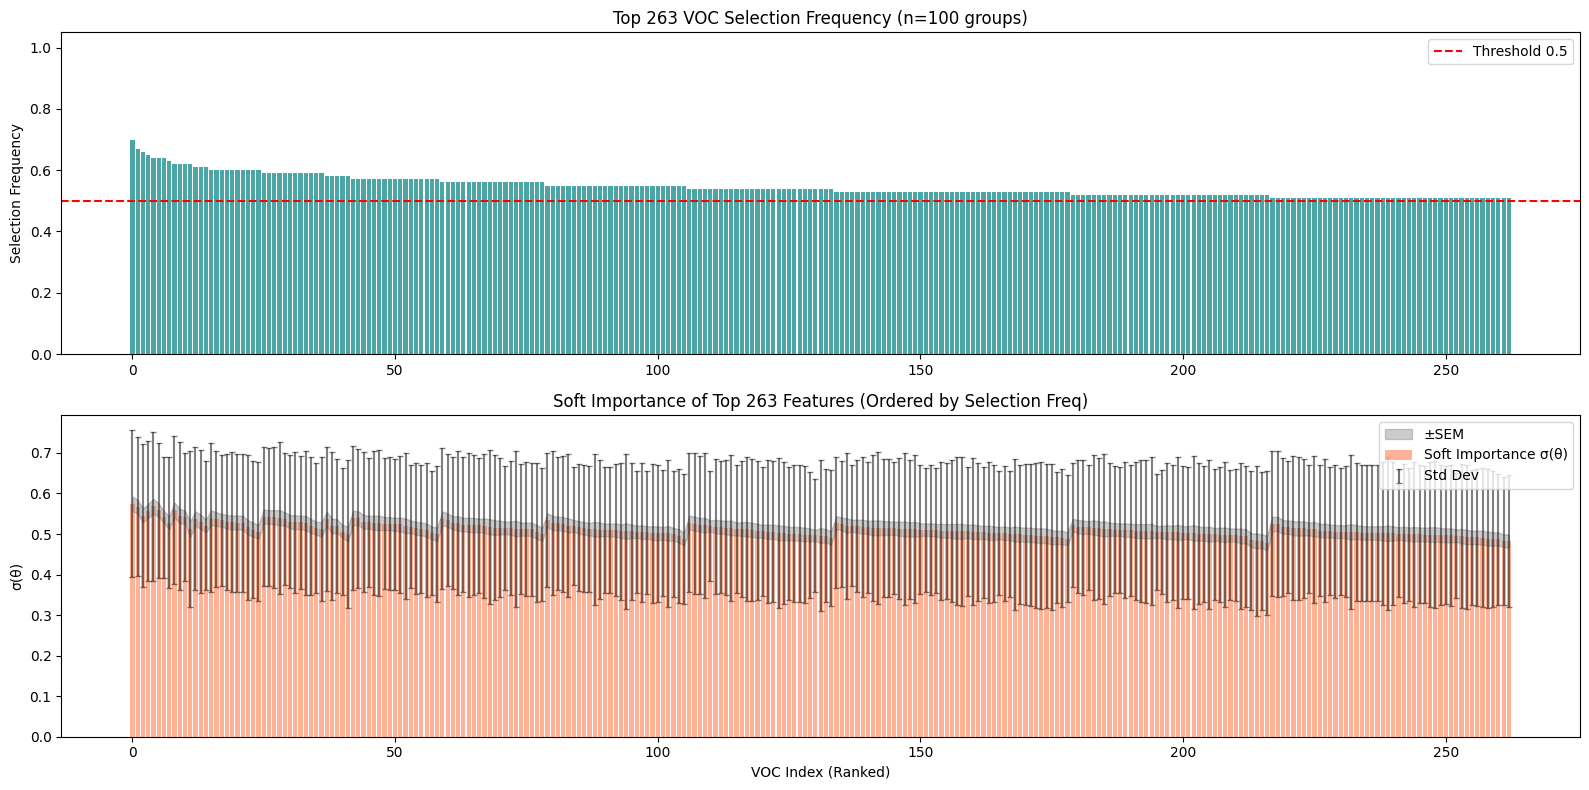

[保存⑩] 特征重要性图 → ./result\feature_importance.png


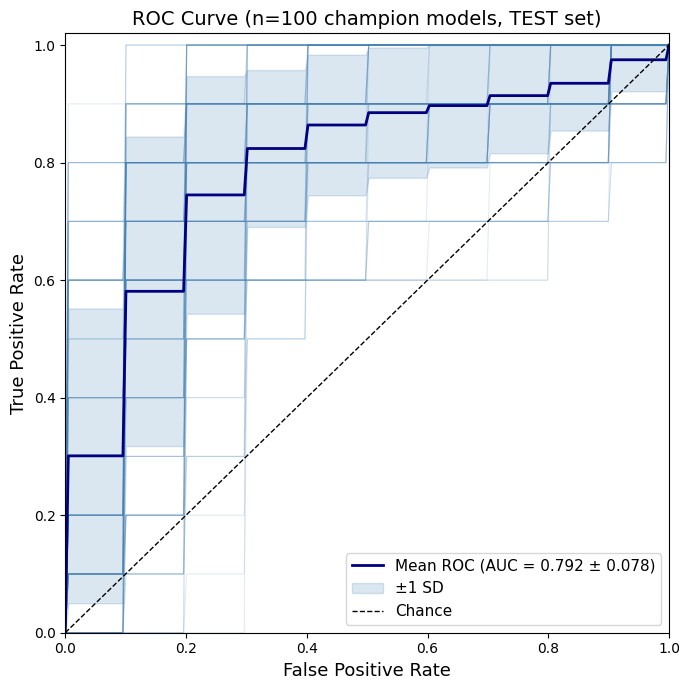

[保存⑪] ROC 曲线 → ./result\roc_curve.png

 🌟 Final Report: averaged over 100 champion models (TEST set)
------------------------------------------------------------
Metric            Mean                95% CI
Sensitivity      0.835        [0.808, 0.862]
Specificity      0.834        [0.810, 0.858]
PPV              0.851        [0.834, 0.869]
NPV              0.855        [0.835, 0.876]
Accuracy         0.834        [0.824, 0.845]
F1               0.831        [0.818, 0.843]
AUC              0.792        [0.776, 0.808]
------------------------------------------------------------
acc: 83.45%±1.03%.
precision: 85.13%±1.75%.
recall: 83.50%±2.65%.
fpr: 16.60%±2.35%.
f1: 83.09%±1.25%.


In [2]:
# experiment('./data/1_and_2.mat', './result/mask_l_results1-2.pt', num_cluster=3, experiment_repeats=100, repeats=10, epochs=300)
experiment('./data/1_and_2.mat', './result/1_and_2', num_cluster = 3, experiment_repeats=100, repeats=30, epochs=300, sparsity_lambda=1e-2, temp_start=1.0, temp_end=0.3,seed=42, panel_threshold=0.5)

100%|██████████| 100/100 [14:32:57<00:00, 523.77s/it] 


[保存] 100 个冠军模型权重 → ./result/champion_model_repeat*.pt
[保存①] 原始二值 mask → ./result/1_and_3
[保存②] 运行配置 → ./result\run_config.json
[保存③] 特征选择统计 → ./result\feature_selection_stats.csv
[保存④] 入选 VOC panel（freq>0.5，共 267 个）→ ./result\selected_voc_panel.csv
[保存⑤] 混淆矩阵均值 → ./result\confusion_matrix_summary.csv
[保存⑥a] 逐组诊断指标 → ./result\metrics_per_repeat.csv
[保存⑥b] 诊断指标汇总（均值±95%CI）→ ./result\metrics_summary.csv
[保存⑦] 原始软概率与标签 → ./result\raw_probs_targets.npz
[保存⑧] 画图用数据 → ./result\plot_data.npz
[保存⑨] 逐组AUC → ./result\auc_per_group.csv


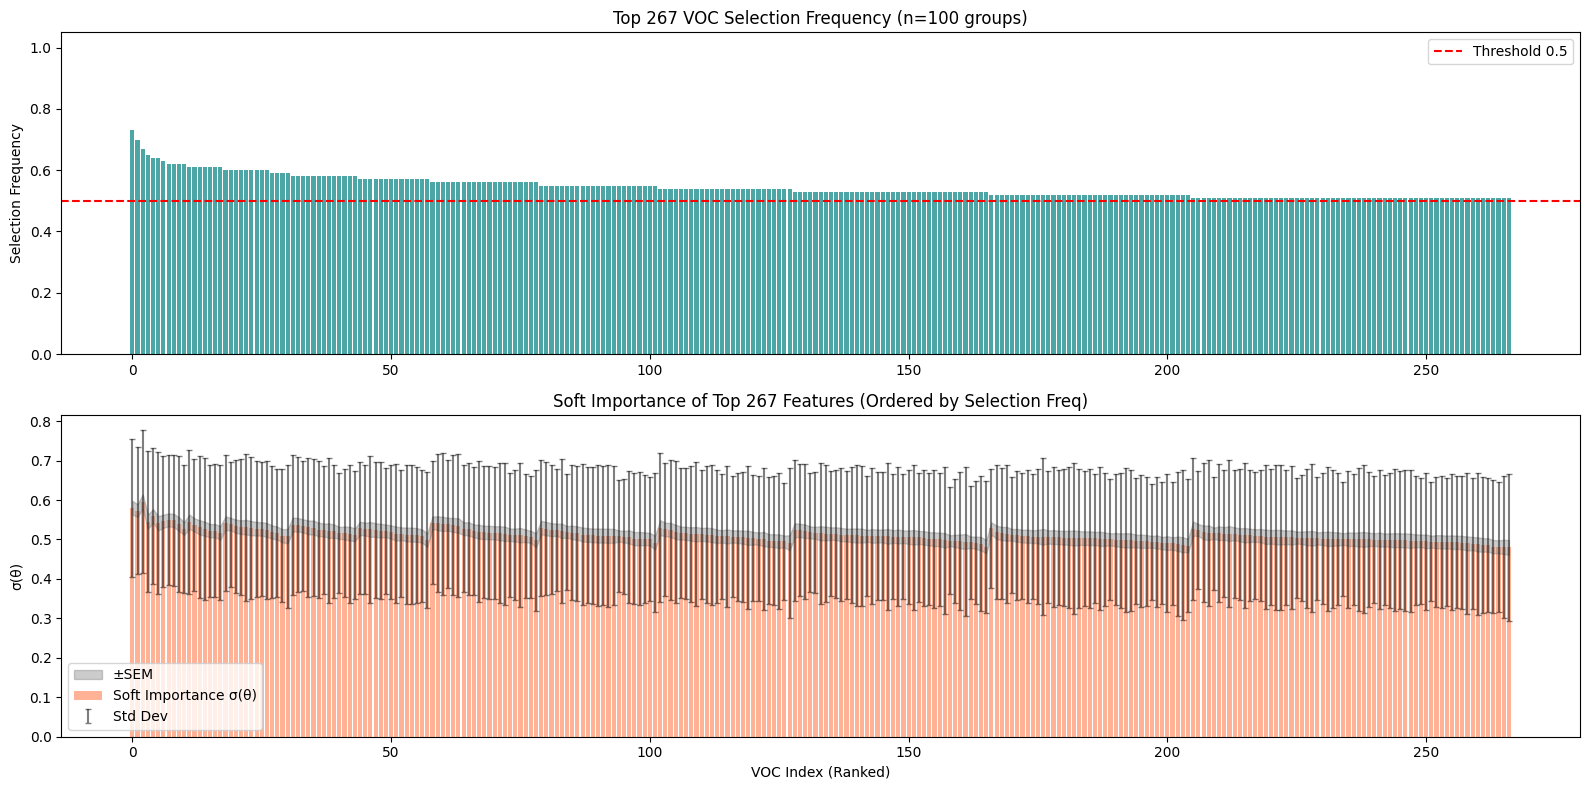

[保存⑩] 特征重要性图 → ./result\feature_importance.png


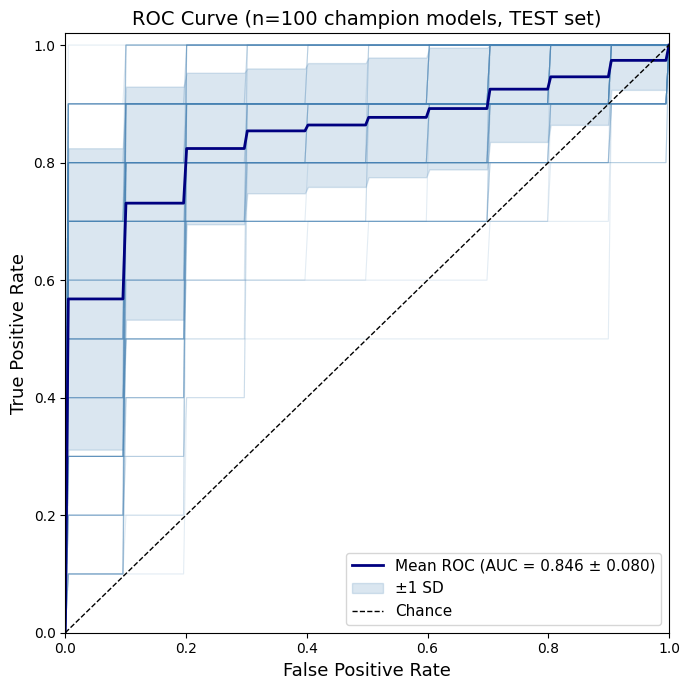

[保存⑪] ROC 曲线 → ./result\roc_curve.png

 🌟 Final Report: averaged over 100 champion models (TEST set)
------------------------------------------------------------
Metric            Mean                95% CI
Sensitivity      0.835        [0.813, 0.857]
Specificity      0.912        [0.892, 0.932]
PPV              0.919        [0.902, 0.936]
NPV              0.858        [0.842, 0.875]
Accuracy         0.873        [0.864, 0.883]
F1               0.866        [0.855, 0.878]
AUC              0.846        [0.830, 0.861]
------------------------------------------------------------
acc: 87.35%±0.97%.
precision: 91.91%±1.68%.
recall: 83.50%±2.18%.
fpr: 8.80%±1.94%.
f1: 86.62%±1.12%.


In [6]:
experiment('./data/1_and_3.mat', './result/1_and_3', num_cluster = 3, experiment_repeats=100, repeats=30, epochs=300, sparsity_lambda=1e-2, temp_start=1.0, temp_end=0.3,seed=42, panel_threshold=0.5)

100%|██████████| 100/100 [12:07:37<00:00, 436.57s/it] 


[保存] 100 个冠军模型权重 → ./result/champion_model_repeat*.pt
[保存①] 原始二值 mask → ./result/2_and_3
[保存②] 运行配置 → ./result\run_config.json
[保存③] 特征选择统计 → ./result\feature_selection_stats.csv
[保存④] 入选 VOC panel（freq>0.5，共 296 个）→ ./result\selected_voc_panel.csv
[保存⑤] 混淆矩阵均值 → ./result\confusion_matrix_summary.csv
[保存⑥a] 逐组诊断指标 → ./result\metrics_per_repeat.csv
[保存⑥b] 诊断指标汇总（均值±95%CI）→ ./result\metrics_summary.csv
[保存⑦] 原始软概率与标签 → ./result\raw_probs_targets.npz
[保存⑧] 画图用数据 → ./result\plot_data.npz
[保存⑨] 逐组AUC → ./result\auc_per_group.csv


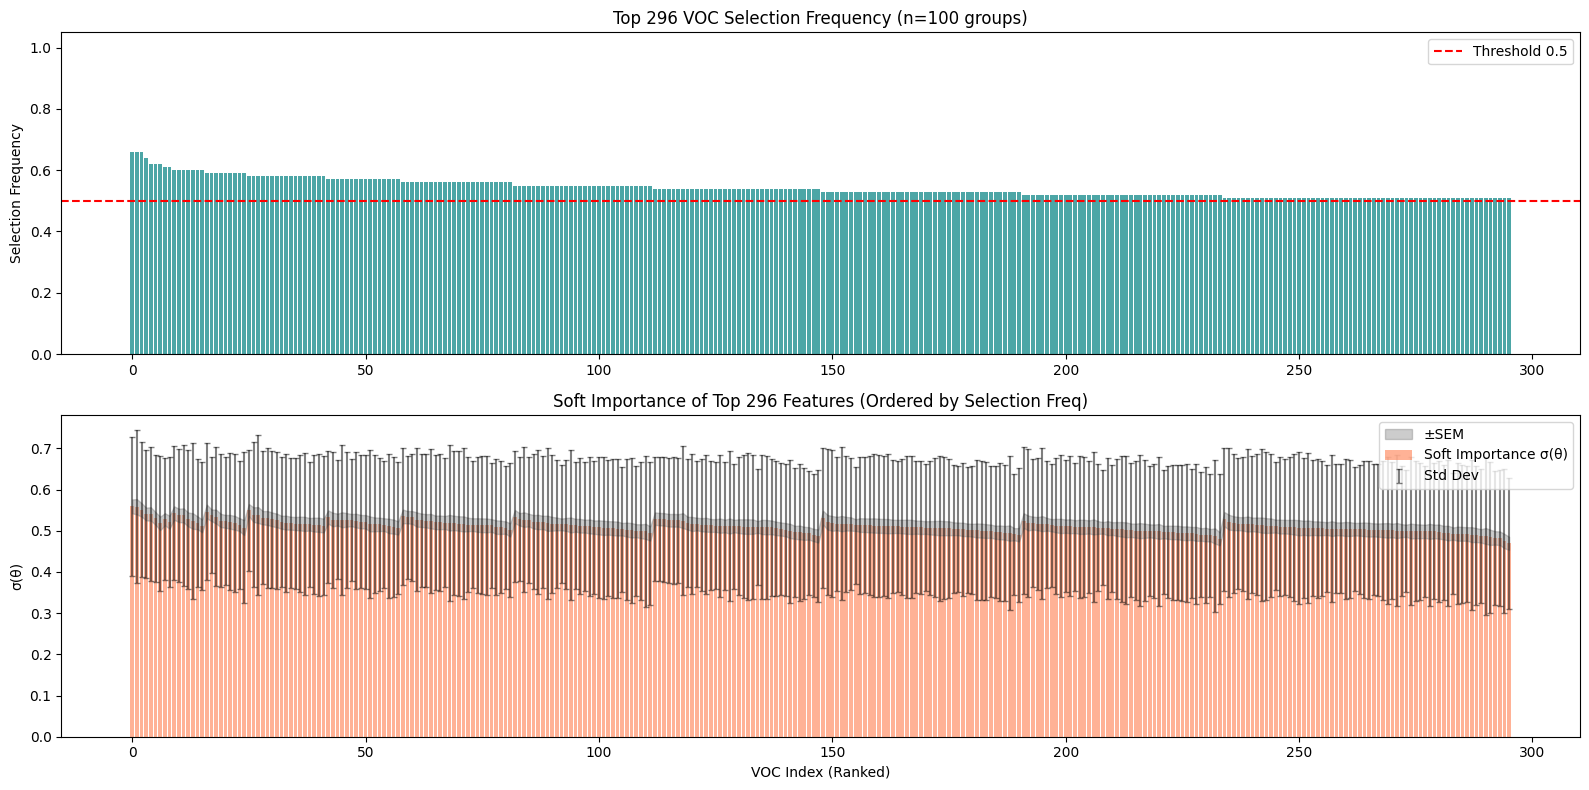

[保存⑩] 特征重要性图 → ./result\feature_importance.png


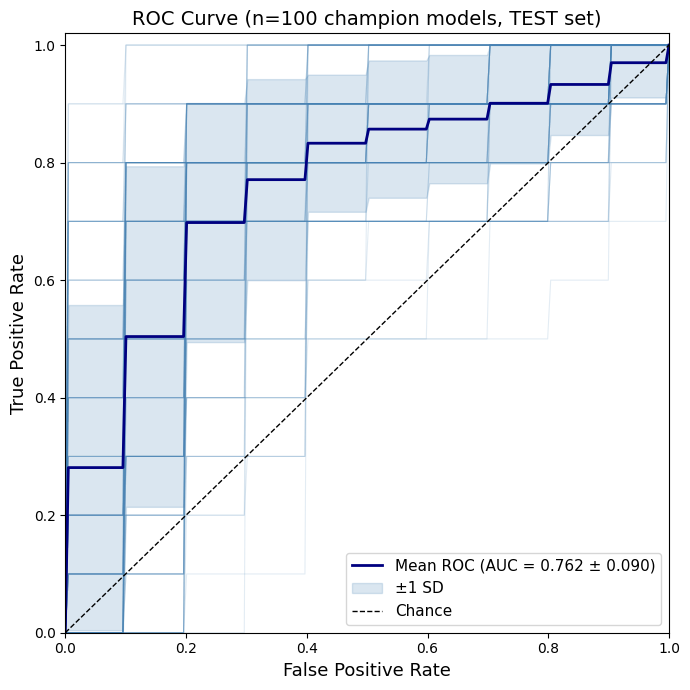

[保存⑪] ROC 曲线 → ./result\roc_curve.png

 🌟 Final Report: averaged over 100 champion models (TEST set)
------------------------------------------------------------
Metric            Mean                95% CI
Sensitivity      0.811        [0.786, 0.836]
Specificity      0.809        [0.783, 0.835]
PPV              0.828        [0.809, 0.847]
NPV              0.829        [0.811, 0.848]
Accuracy         0.810        [0.800, 0.820]
F1               0.807        [0.795, 0.820]
AUC              0.762        [0.744, 0.780]
------------------------------------------------------------
acc: 81.00%±1.02%.
precision: 82.79%±1.85%.
recall: 81.10%±2.51%.
fpr: 19.10%±2.58%.
f1: 80.73%±1.22%.


In [5]:
experiment('./data/2_and_3.mat', './result/2_and_3', num_cluster = 3, experiment_repeats=100, repeats=30, epochs=300, sparsity_lambda=1e-2, temp_start=1.0, temp_end=0.3,seed=42, panel_threshold=0.5)

100%|██████████| 100/100 [21:06:22<00:00, 759.83s/it]  


[保存] 100 个冠军模型权重 → ./result/champion_model_repeat*.pt
[保存①] 原始二值 mask → ./result/1+2_and_3
[保存②] 运行配置 → ./result\run_config.json
[保存③] 特征选择统计 → ./result\feature_selection_stats.csv
[保存④] 入选 VOC panel（freq>0.5，共 240 个）→ ./result\selected_voc_panel.csv
[保存⑤] 混淆矩阵均值 → ./result\confusion_matrix_summary.csv
[保存⑥a] 逐组诊断指标 → ./result\metrics_per_repeat.csv
[保存⑥b] 诊断指标汇总（均值±95%CI）→ ./result\metrics_summary.csv
[保存⑦] 原始软概率与标签 → ./result\raw_probs_targets.npz
[保存⑧] 画图用数据 → ./result\plot_data.npz
[保存⑨] 逐组AUC → ./result\auc_per_group.csv


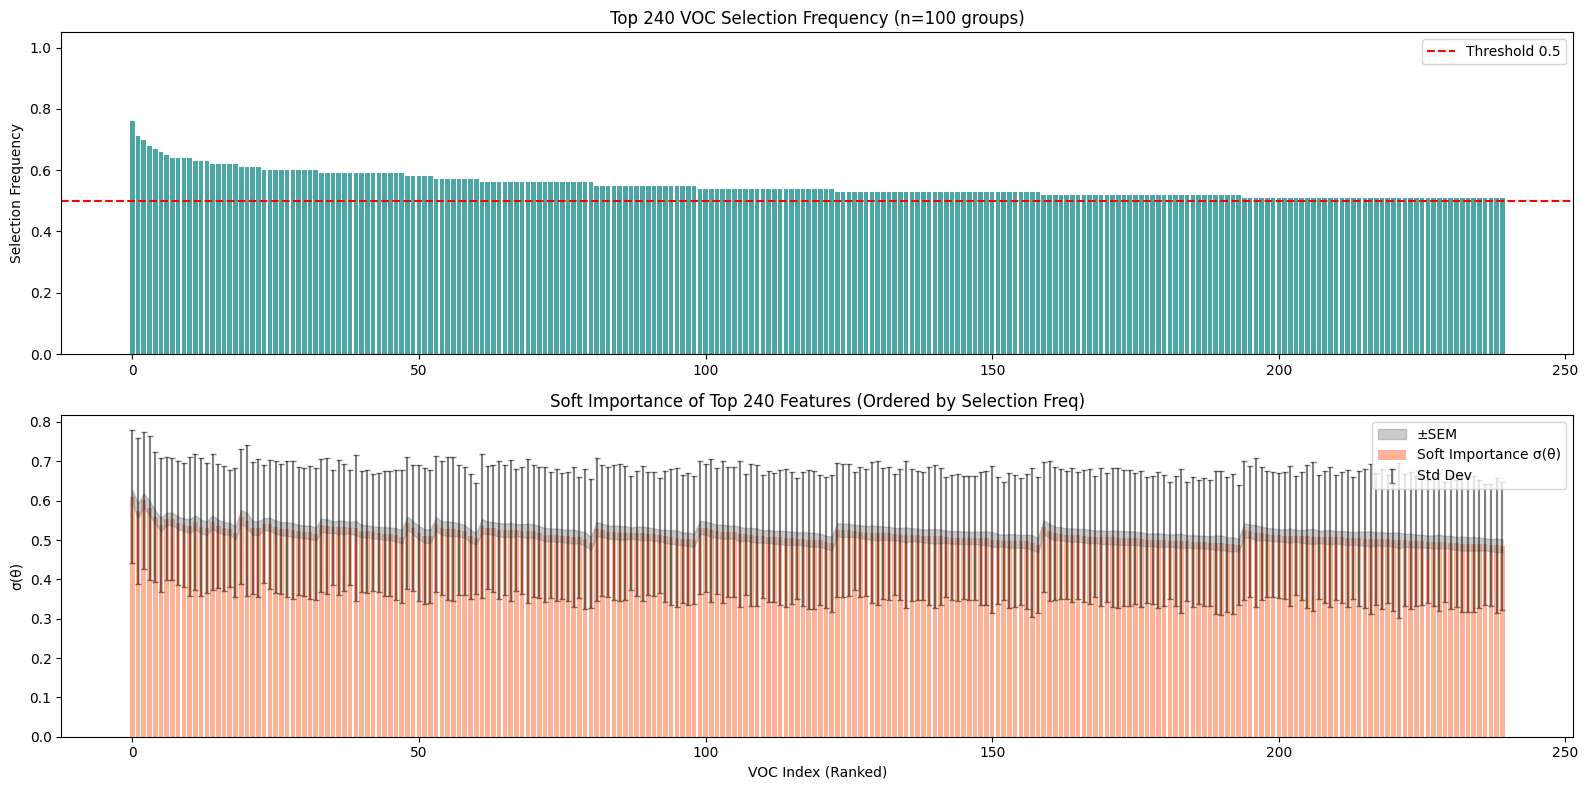

[保存⑩] 特征重要性图 → ./result\feature_importance.png


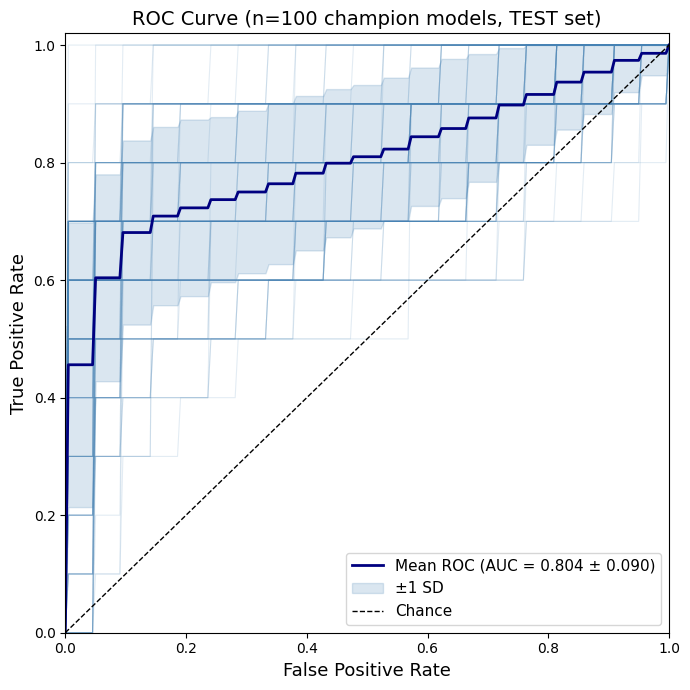

[保存⑪] ROC 曲线 → ./result\roc_curve.png

 🌟 Final Report: averaged over 100 champion models (TEST set)
------------------------------------------------------------
Metric            Mean                95% CI
Sensitivity      0.689        [0.658, 0.720]
Specificity      0.960        [0.950, 0.971]
PPV              0.916        [0.897, 0.936]
NPV              0.872        [0.860, 0.883]
Accuracy         0.873        [0.865, 0.881]
F1               0.769        [0.750, 0.788]
AUC              0.804        [0.786, 0.822]
------------------------------------------------------------
acc: 87.29%±0.82%.
precision: 91.63%±1.95%.
recall: 68.90%±3.09%.
fpr: 3.95%±1.04%.
f1: 76.90%±1.91%.


In [39]:
experiment('./data/1+2_and_3.mat', './result/1+2_and_3', num_cluster = 3, experiment_repeats=100, repeats=30, epochs=300, sparsity_lambda=1e-2, temp_start=1.0, temp_end=0.3,seed=42, panel_threshold=0.5)

In [16]:
import scipy.io as sio
import numpy as np

# 读取 mat 文件
data_path = './data/1+2_and_3.mat'
data = sio.loadmat(data_path)

# 查看文件中包含哪些变量
print("=" * 60)
print("📁 Mat 文件中的变量:")
print("=" * 60)
for key in data.keys():
    if not key.startswith('__'):  # 过滤掉元数据
        print(f"  - {key}: {type(data[key])}, shape={getattr(data[key], 'shape', 'N/A')}")

print("\n" + "=" * 60)
print("📊 详细数据:")
print("=" * 60)

# 查看 X (特征数据)
if 'X' in data:
    X = data['X']
    print(f"\n🔢 X (特征数据):")
    print(f"  - 类型: {type(X)}")
    print(f"  - 形状: {X.shape}")
    print(f"  - 数据类型: {X.dtype}")
    print(f"  - 最小值: {X.min():.4f}")
    print(f"  - 最大值: {X.max():.4f}")
    print(f"  - 均值: {X.mean():.4f}")
    print(f"  - 标准差: {X.std():.4f}")
    print(f"  - 前5行 (前5个样本, 前10个特征):\n{X[:5, :10]}")

# 查看 y (标签)
if 'y' in data:
    y = data['y']
    print(f"\n🏷️ y (标签):")
    print(f"  - 类型: {type(y)}")
    print(f"  - 形状: {y.shape}")
    print(f"  - 数据类型: {y.dtype}")
    print(f"  - 唯一值: {np.unique(y)}")
    print(f"  - 每个类别的样本数:")
    for label in np.unique(y):
        count = np.sum(y == label)
        print(f"      类别 {label}: {count} 个样本 ({count/len(y)*100:.1f}%)")
    print(f"  - 前20个标签: {y.flatten()[:20]}")

# 查看 voc_names (特征名称)
if 'voc_names' in data:
    voc_names = data['voc_names']
    print(f"\n📝 voc_names (特征名称):")
    print(f"  - 类型: {type(voc_names)}")
    print(f"  - 形状: {voc_names.shape}")
    print(f"  - 前10个特征名称:")
    for i in range(min(10, len(voc_names.flatten()))):
        print(f"      {i}: {voc_names.flatten()[i]}")

# 检查其他可能的变量
print("\n" + "=" * 60)
print("🔍 其他变量:")
print("=" * 60)
for key in data.keys():
    if not key.startswith('__') and key not in ['X', 'y', 'voc_names']:
        print(f"  - {key}: shape={data[key].shape if hasattr(data[key], 'shape') else 'N/A'}")

# 确认类别数（根据你的描述 "53+53 vs 53" 应该是3类）
print("\n" + "=" * 60)
print("📈 类别分布分析:")
print("=" * 60)
if 'y' in data:
    y_flat = y.flatten()
    unique_labels = np.unique(y_flat)
    print(f"总样本数: {len(y_flat)}")
    print(f"类别数: {len(unique_labels)}")
    print(f"类别分布: {dict(zip(*np.unique(y_flat, return_counts=True)))}")
    
    # 猜测：如果是 "53+53 vs 53"，可能是 [53, 53, 53] 或 [106, 53]
    # 检查哪种符合
    counts = [np.sum(y_flat == label) for label in unique_labels]
    if len(counts) == 2:
        print(f"\n⚠️ 这是二分类问题")
        if min(counts) * 2 == max(counts):
            print(f"   可能是 {min(counts)} vs {max(counts)} (比例 1:2)")
    elif len(counts) == 3:
        print(f"\n✅ 这是三分类问题")
        if len(set(counts)) == 1:
            print(f"   平衡的三分类: 每类 {counts[0]} 个样本")
        else:
            print(f"   不平衡的三分类: {counts}")

📁 Mat 文件中的变量:
  - X: <class 'numpy.ndarray'>, shape=(159, 699)
  - y: <class 'numpy.ndarray'>, shape=(1, 159)
  - voc_names: <class 'numpy.ndarray'>, shape=(1, 699)

📊 详细数据:

🔢 X (特征数据):
  - 类型: <class 'numpy.ndarray'>
  - 形状: (159, 699)
  - 数据类型: float64
  - 最小值: 0.0000
  - 最大值: 18.2058
  - 均值: 8.1645
  - 标准差: 2.6025
  - 前5行 (前5个样本, 前10个特征):
[[ 9.54871651 10.95942492 11.3038638  12.44545326 14.24477292 12.97664048
  10.33933734 12.4092249  13.05749157  7.29958315]
 [ 5.26802979  7.11289778  5.27060336  6.46873328  7.56694073  7.8844259
   7.08964591  7.12266503  7.43554598  8.43082517]
 [ 6.71447388  2.79116511  5.22511906  7.55185244  9.78614161  4.03187785
   7.2082672   9.13103371  2.84490938  9.84895903]
 [ 8.00078535  8.54756409  5.02978411  5.86618473  7.44546604  8.81929579
   8.58835672  6.70392404  8.81929579  8.84061637]
 [ 8.02143121  8.18844826  7.48995246  7.5184894   8.4083747   7.00311091
   8.3462981  11.48685763 16.85396275  9.8285808 ]]

🏷️ y (标签):
  - 类型: <class 'nu